# SMS Spam Detection with Naive Bayes

This notebook cleans the SMS Spam Collection messages, turns them into word counts with `CountVectorizer`, and trains a Multinomial Naive Bayes classifier. It reaches 97.58% accuracy with 0.9552 precision and 0.8591 recall on the test set, and it also shows which words the model links most to spam and to ham.

## 1. Imports and loading the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

import glob, os

def find_file(name):
    # on Kaggle the attached dataset lives under /kaggle/input
    hits = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    return hits[0] if hits else name   # fallback: same folder (for running locally)

spam_df = pd.read_csv(find_file('spam.csv'), encoding='latin-1', usecols=['v1', 'v2'])

print("Shape:", spam_df.shape)
print(spam_df.head())
print("\nClass balance:")
print(spam_df['v1'].value_counts())
print((spam_df['v1'].value_counts(normalize=True) * 100).round(2))

Shape: (5572, 2)
     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Class balance:
v1
ham     4825
spam     747
Name: count, dtype: int64
v1
ham     86.59
spam    13.41
Name: proportion, dtype: float64


The dataset has 5,572 SMS messages. 4,825 are ham (86.59%) and 747 are spam (13.41%), so the classes are imbalanced.

## 2. Cleaning and vectorization

In [2]:
# lowercase and remove punctuation
spam_df['v2'] = spam_df['v2'].str.lower()
spam_df['v2'] = spam_df['v2'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

# encode labels: ham = 0, spam = 1
spam_df['label'] = spam_df['v1'].map({'ham': 0, 'spam': 1})

X = spam_df['v2']
y = spam_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# fit the vectorizer on the training messages only
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
print("Training data shape:", X_train_vec.shape)
print("Testing data shape:", X_test_vec.shape)

Vocabulary size: 8343
Training data shape: (4457, 8343)
Testing data shape: (1115, 8343)


The vectorizer learned 8,343 words from the training messages only. Fitting it on the full data would leak test words into the vocabulary.

## 3. Naive Bayes model and evaluation

Accuracy : 0.9758
Precision: 0.9552
Recall   : 0.8591
F1-score : 0.9046

Confusion matrix:
 [[960   6]
 [ 21 128]]


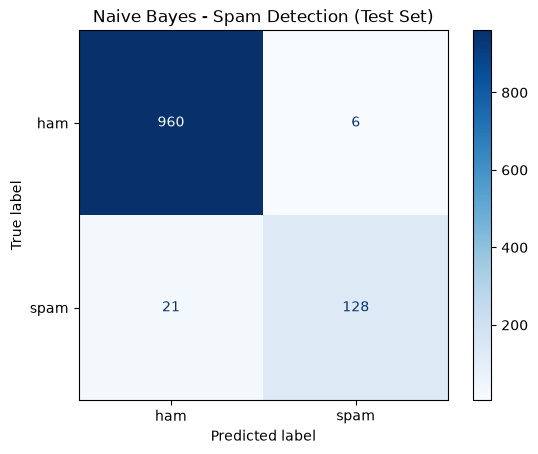

In [3]:
nb_spam = MultinomialNB()
nb_spam.fit(X_train_vec, y_train)

y_pred = nb_spam.predict(X_test_vec)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:\n", cm)

ConfusionMatrixDisplay(cm, display_labels=['ham', 'spam']).plot(cmap='Blues')
plt.title('Naive Bayes - Spam Detection (Test Set)')
plt.show()

The model caught 128 spam messages and missed 21. It wrongly flagged only 6 real messages as spam. A false positive is the worse mistake here because a real message could get hidden, so precision matters most, and it is already high at 0.9552.

## 4. Which words does the model link to spam and ham?

In [4]:
words = vectorizer.get_feature_names_out()

# log P(word | spam) - log P(word | ham)
log_diff = nb_spam.feature_log_prob_[1] - nb_spam.feature_log_prob_[0]

top_spam_idx = np.argsort(log_diff)[::-1][:15]
top_ham_idx = np.argsort(log_diff)[:15]

print("Top 15 spam words:")
for i in top_spam_idx:
    print(f"  {words[i]:<12} {log_diff[i]:.3f}")

print("\nTop 15 ham words:")
for i in top_ham_idx:
    print(f"  {words[i]:<12} {log_diff[i]:.3f}")

Top 15 spam words:
  claim        5.533
  prize        5.184
  won          5.057
  500          4.617
  tone         4.617
  guaranteed   4.617
  18           4.534
  1000         4.505
  150          4.380
  tcs          4.346
  150ppm       4.346
  awarded      4.311
  urgent       4.256
  collection   4.237
  award        4.198

Top 15 ham words:
  ltgt         -4.437
  ill          -4.309
  he           -3.881
  lor          -3.873
  later        -3.775
  da           -3.766
  she          -3.596
  thats        -3.415
  my           -3.317
  doing        -3.255
  say          -3.255
  really       -3.255
  ask          -3.240
  didnt        -3.240
  anything     -3.226


The spam words (claim, prize, won, awarded, guaranteed, urgent) are the usual "you won something" language. The ham words are normal chat words like ill, he, she and later. `ltgt` is a leftover from how the dataset stores the symbols "<" and ">".

## 5. Testing my own messages

In [5]:
my_messages = [
    "WINNER!! You have won a free prize. Call now to claim your cash reward",
    "Hey, are we still meeting at the library after class tomorrow?",
    "URGENT! Your mobile number has won a 1000 cash prize. Text CLAIM to 80086 now",
]

# same cleaning as the training data
cleaned = (pd.Series(my_messages).str.lower()
           .str.replace(r'[^a-zA-Z0-9\s]', '', regex=True))

vec = vectorizer.transform(cleaned)
pred = nb_spam.predict(vec)
prob = nb_spam.predict_proba(vec)[:, 1]

for msg, p, pr in zip(my_messages, pred, prob):
    print(f"Message: {msg}")
    print(f"Prediction: {'spam' if p == 1 else 'ham'}  (P(spam) = {pr:.4f})\n")

Message: WINNER!! You have won a free prize. Call now to claim your cash reward
Prediction: spam  (P(spam) = 1.0000)

Message: Hey, are we still meeting at the library after class tomorrow?
Prediction: ham  (P(spam) = 0.0000)

Message: URGENT! Your mobile number has won a 1000 cash prize. Text CLAIM to 80086 now
Prediction: spam  (P(spam) = 1.0000)



The two spam-like messages were predicted as spam and the normal message as ham, which is what I expected.